In [1]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [2]:
water_engineered_path = PATHS['engineered_data'] / 'water_engineered.parquet'
df = pd.read_parquet(water_engineered_path)
df.head()

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
0,1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN,1
1,1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0,2
2,1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0,3
3,1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0,4
4,1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0,5


In [9]:
from sklearn.preprocessing import MinMaxScaler

reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
df_res.set_index('date', inplace=True)

capacity = df_res['capacity'].iloc[0]

df_res.drop(columns=['id', 'province', 'autonomous_community', 'day', 'capacity', 'crest_elevation'], inplace=True)

# Train/test split: last 52 weeks as test
train = df_res.iloc[-(52*6):-52]
test = df_res.iloc[-52:]

# Convert storage-related features to percentages (divide by capacity)
train.loc[:, 'storage'] = train.loc[:, 'storage'] / capacity
train.loc[:, 'storage_last_week_1'] = train.loc[:, 'storage_last_week_1'] / capacity
train.loc[:, 'storage_last_week_2'] = train.loc[:, 'storage_last_week_2'] / capacity
train.loc[:, 'storage_last_week_3'] = train.loc[:, 'storage_last_week_3'] / capacity
train.loc[:, 'storage_last_week_4'] = train.loc[:, 'storage_last_week_4'] / capacity
train.loc[:, 'storage_last_year'] = train.loc[:, 'storage_last_year'] / capacity
train.loc[:, 'storage_mean_4w'] = train.loc[:, 'storage_mean_4w'] / capacity
train.loc[:, 'storage_std_4w'] = train.loc[:, 'storage_std_4w'] / capacity

year_scaler = MinMaxScaler()
train.loc[:, 'year'] = train['year'].astype(float)
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()

train.loc[:, 'month'] = train.loc[:, 'month'] / 12
train.loc[:, 'week_idx'] = train.loc[:, 'week_idx'] / 52

train.head()

C:\Users\usuario\AppData\Local\Temp\ipykernel_25192\1649970064.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8
 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8
 0.8 0.8 

,storage,year,month,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
date,,,,,,,,,,,,
2018-10-09,0.909910,0.0,0.833333,0,0.909910,0.909910,0.909910,0.90991,0.513514,0.909910,0.000000,0.788462
2018-10-16,0.900901,0.0,0.833333,0,0.909910,0.909910,0.909910,0.90991,0.495495,0.907658,0.004505,0.807692
2018-10-23,0.909910,0.0,0.833333,0,0.900901,0.909910,0.909910,0.90991,0.486486,0.907658,0.004505,0.826923
2018-10-30,0.909910,0.0,0.833333,0,0.909910,0.900901,0.909910,0.90991,0.477477,0.907658,0.004505,0.846154
2018-11-06,0.909910,0.0,0.916667,0,0.909910,0.909910,0.900901,0.90991,0.468468,0.907658,0.004505,0.865385


In [10]:
test.loc[:, 'storage'] = test.loc[:, 'storage'] / capacity
test.loc[:, 'storage_last_week_1'] = test.loc[:, 'storage_last_week_1'] / capacity
test.loc[:, 'storage_last_week_2'] = test.loc[:, 'storage_last_week_2'] / capacity
test.loc[:, 'storage_last_week_3'] = test.loc[:, 'storage_last_week_3'] / capacity
test.loc[:, 'storage_last_week_4'] = test.loc[:, 'storage_last_week_4'] / capacity
test.loc[:, 'storage_last_year'] = test.loc[:, 'storage_last_year'] / capacity
test.loc[:, 'storage_mean_4w'] = test.loc[:, 'storage_mean_4w'] / capacity
test.loc[:, 'storage_std_4w'] = test.loc[:, 'storage_std_4w'] / capacity

test.loc[:, 'year'] = year_scaler.transform(test['year'].values.reshape(-1, 1)).flatten()
test.loc[:, 'month'] = test.loc[:, 'month'] / 12
test.loc[:, 'week_idx'] = test.loc[:, 'week_idx'] / 52

test.head()


C:\Users\usuario\AppData\Local\Temp\ipykernel_25192\1986514308.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.2 1.2 1.2 1.2 1.2
 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2
 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  test.loc[:, 'year'] = year_scaler.transform(test['year'].values.reshape(-1, 1)).flatten()
C:\Users\usuario\AppData\Local\Temp\ipykernel_25192\1986514308.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.91666667
 0.91666667 0.91666667 0.91666667 1.         1.         1.
 1.         0.08333333 0.08333333 0.08333333 0.08333333 0.08333333
 0.16666667 0.16666667 0.16666667 0.166

,storage,year,month,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
date,,,,,,,,,,,,
2023-10-03,0.369369,1.0,0.833333,0,0.378378,0.396396,0.405405,0.414414,0.603604,0.387387,0.016448,0.769231
2023-10-10,0.360360,1.0,0.833333,0,0.369369,0.378378,0.396396,0.405405,0.594595,0.376126,0.015386,0.788462
2023-10-17,0.351351,1.0,0.833333,0,0.360360,0.369369,0.378378,0.396396,0.585586,0.364865,0.011631,0.807692
2023-10-24,0.351351,1.0,0.833333,0,0.351351,0.360360,0.369369,0.378378,0.576577,0.358108,0.008625,0.826923
2023-10-31,0.351351,1.0,0.833333,0,0.351351,0.351351,0.360360,0.369369,0.567568,0.353604,0.004505,0.846154


In [ ]:
from backend.modeling.xgboost_model import XGBoostModel
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(train)

# Since XGBoost only supports 1-step prediction, we need to do walk-forward forecasting
forecast_values = []

for step in range(52):
    # Predict next step (automatically updates features internally)
    pred = model.predict(steps=1)[0]
    forecast_values.append(pred)

# Create forecast series with same index as test
forecast = pd.Series(forecast_values, index=test.index)

def adjust_negatives(predictions):
    """Adjust negative values in predictions"""
    predictions = np.array(predictions)
    for i in range(len(predictions)):
        if predictions[i] < 0:
            correction = -predictions[i]
            predictions[i:] += correction
    return predictions

forecast = forecast*capacity  # Scale back to original capacity

forecast = adjust_negatives(forecast)

results = model.evaluate(test, forecast)

# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

In [22]:
from sklearn.preprocessing import MinMaxScaler

reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
df_res.set_index('date', inplace=True)

capacity = df_res['capacity'].iloc[0]

# df_res.drop(columns=['id', 'province', 'autonomous_community', 'day', 'capacity', 'crest_elevation', 'storage_mean_4w', 'storage_std_4w'], inplace=True)

df_res = df_res.iloc[-(52*8):]

# Keep only storage for lag feature creation
storage_series = df_res['storage'] / capacity  # Convert to percentage

# Create lag features for the last 3 years
YEARS_BACK = 3
weeks_back = 52 * YEARS_BACK  # 156 weeks

# Create all lag features efficiently using pd.concat
lag_features = {}
for lag in range(1, weeks_back + 1):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features
}, index=storage_series.index)

# Remove rows with NaN values (first 3 years and last row)
lag_data = lag_data.dropna()

print(f"Original data shape: {df_res.shape}")
print(f"Prepared data shape: {lag_data.shape}")
print(f"Features created: {lag_data.shape[1] - 1} (excluding target)")
print(f"Lag features: {weeks_back}")

# Split into train/test: last 52 weeks as test
train = lag_data.iloc[:-52]
test_features = lag_data.iloc[-52:].drop('next_storage_value', axis=1)
test_target = lag_data.iloc[-52:]['next_storage_value']

# Scale year feature
year_scaler = MinMaxScaler()
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()
test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()

print(f"Training data shape: {train.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Test target shape: {test_target.shape}")

train.head()

Original data shape: (416, 18)
Prepared data shape: (259, 160)
Features created: 159 (excluding target)
Lag features: 156
Training data shape: (207, 160)
Test features shape: (52, 159)
Test target shape: (52,)


,year,month,week_idx,next_storage_value,storage_lag_1,storage_lag_2,storage_lag_3,storage_lag_4,storage_lag_5,storage_lag_6,...,storage_lag_147,storage_lag_148,storage_lag_149,storage_lag_150,storage_lag_151,storage_lag_152,storage_lag_153,storage_lag_154,storage_lag_155,storage_lag_156
date,,,,,,,,,,,,,,,,,,,,,
2019-10-08,0.0,0.833333,0.788462,0.819820,0.837838,0.855856,0.855856,0.864865,0.873874,0.891892,...,0.504505,0.504505,0.504505,0.495495,0.513514,0.513514,0.522523,0.531532,0.540541,0.549550
2019-10-15,0.0,0.833333,0.807692,0.810811,0.828829,0.837838,0.855856,0.855856,0.864865,0.873874,...,0.522523,0.504505,0.504505,0.504505,0.495495,0.513514,0.513514,0.522523,0.531532,0.540541
2019-10-22,0.0,0.833333,0.826923,0.801802,0.819820,0.828829,0.837838,0.855856,0.855856,0.864865,...,0.531532,0.522523,0.504505,0.504505,0.504505,0.495495,0.513514,0.513514,0.522523,0.531532
2019-10-29,0.0,0.833333,0.846154,0.792793,0.810811,0.819820,0.828829,0.837838,0.855856,0.855856,...,0.531532,0.531532,0.522523,0.504505,0.504505,0.504505,0.495495,0.513514,0.513514,0.522523
2019-11-05,0.0,0.916667,0.865385,0.783784,0.801802,0.810811,0.819820,0.828829,0.837838,0.855856,...,0.540541,0.531532,0.531532,0.522523,0.504505,0.504505,0.504505,0.495495,0.513514,0.513514


In [ ]:
test = df_res.iloc[-52:]

In [13]:
lag_data.head()

""
date
2010-02-16
2010-02-23
2010-03-02
2010-03-09
2010-03-16


In [16]:
df_res.head()

,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
date,,,,,,,,,,,,,,,,,,
1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN,1
1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0,2
1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0,3
1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0,4
1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0,5


c:\Users\usuario\Desktop\Extra\Reservoir\backend\modeling\xgboost_model.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.training_data = pd.concat([self.training_data, new_df], ignore_index=True)
c:\Users\usuario\Desktop\Extra\Reservoir\backend\modeling\xgboost_model.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.training_data = pd.concat([self.training_data, new_df], ignore_index=True)
c:\Users\usuario\Desktop\Extra\Reservoir\backend\modeling\xgboost_model.py:154: FutureWa

Model Performance:
MAE: 17.16
RMSE: 19.72
MAPE: 38.57%


c:\Users\usuario\Desktop\Extra\Reservoir\backend\modeling\xgboost_model.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.training_data = pd.concat([self.training_data, new_df], ignore_index=True)


AttributeError: 'numpy.ndarray' object has no attribute 'index'

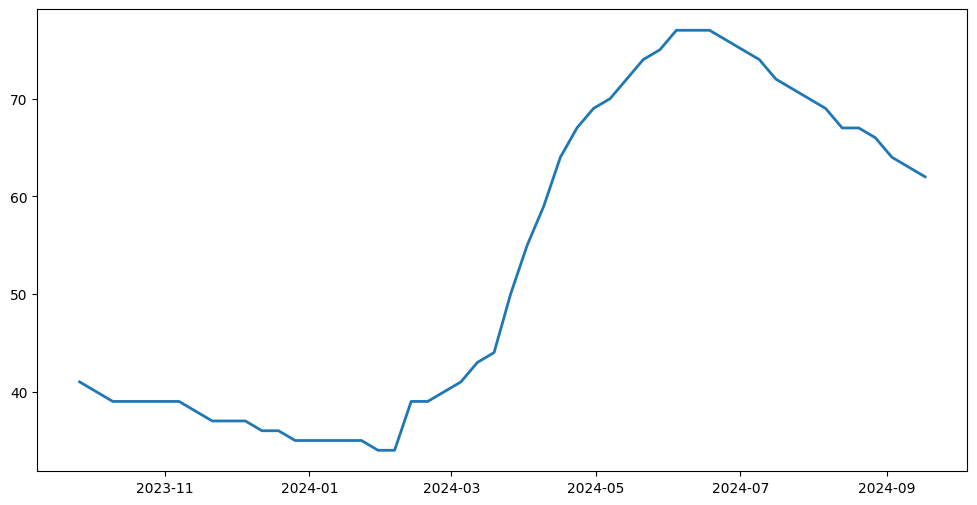

In [ ]:
from sklearn.preprocessing import MinMaxScaler

reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
df_res.set_index('date', inplace=True)

capacity = df_res['capacity'].iloc[0]

# df_res.drop(columns=['id', 'province', 'autonomous_community', 'day', 'capacity', 'crest_elevation', 'storage_mean_4w', 'storage_std_4w'], inplace=True)

df_res = df_res.iloc[-(52*8):]

# Keep only storage for lag feature creation
storage_series = df_res['storage'] / capacity  # Convert to percentage

# Create lag features for the last 3 years
YEARS_BACK = 3
weeks_back = 52 * YEARS_BACK  # 156 weeks

# Create all lag features efficiently using pd.concat
lag_features = {}
for lag in range(1, weeks_back + 1):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features
}, index=storage_series.index)

# Remove rows with NaN values (first 3 years and last row)
lag_data = lag_data.dropna()

print(f"Original data shape: {df_res.shape}")
print(f"Prepared data shape: {lag_data.shape}")
print(f"Features created: {lag_data.shape[1] - 1} (excluding target)")
print(f"Lag features: {weeks_back}")

# Split into train/test: last 52 weeks as test
train = lag_data.iloc[:-52]
test_features = lag_data.iloc[-52:].drop('next_storage_value', axis=1)
test_target = lag_data.iloc[-52:]['next_storage_value']

# Scale year feature
year_scaler = MinMaxScaler()
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()
test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()

print(f"Training data shape: {train.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Test target shape: {test_target.shape}")

train.head()

Original data shape: (416, 19)
Prepared data shape: (259, 161)
Features created: 160 (excluding target)
Lag features: 156
Training data shape: (207, 161)
Test features shape: (52, 160)
Test target shape: (52,)

Model Performance:
mae: 53.2308
mse: 3094.3077
mape: 1.0000


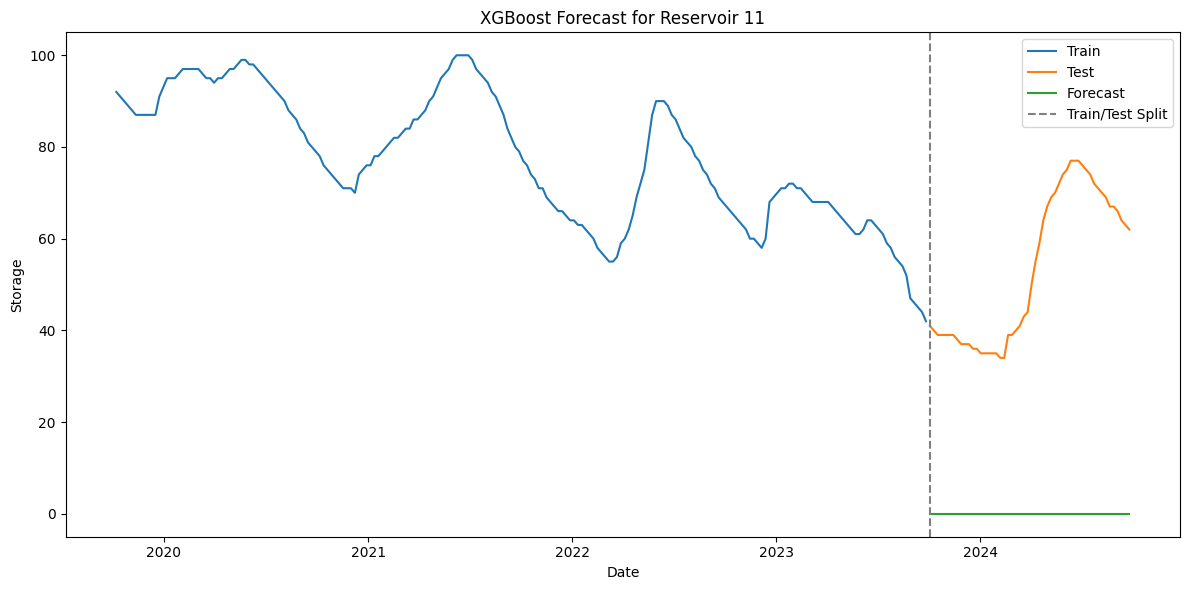

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from backend.modeling.xgboost_model import XGBoostModel

reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
df_res.set_index('date', inplace=True)

capacity = df_res['capacity'].iloc[0]

# df_res.drop(columns=['id', 'province', 'autonomous_community', 'day', 'capacity', 'crest_elevation', 'storage_mean_4w', 'storage_std_4w'], inplace=True)

df_res = df_res.iloc[-(52*8):]

# Keep only storage for lag feature creation
storage_series = df_res['storage'] / capacity  # Convert to percentage

df_res['seasonality'] = 52

# Create lag features for the last 3 years
YEARS_BACK = 2
weeks_back = 52 * YEARS_BACK  # 156 weeks

# Create all lag features efficiently using pd.concat
lag_features = {}
for lag in range(1, weeks_back + 1):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    "seasonality" : df_res['seasonality'],
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features
}, index=storage_series.index)

# Remove rows with NaN values (first 3 years and last row)
lag_data = lag_data.dropna()

print(f"Original data shape: {df_res.shape}")
print(f"Prepared data shape: {lag_data.shape}")
print(f"Features created: {lag_data.shape[1] - 1} (excluding target)")
print(f"Lag features: {weeks_back}")

# Split into train/test: last 52 weeks as test
train = lag_data.iloc[:-52]
test_features = lag_data.iloc[-52:].drop('next_storage_value', axis=1)
test_target = lag_data.iloc[-52:]['next_storage_value']

# Scale year feature
year_scaler = MinMaxScaler()
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()
test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()

print(f"Training data shape: {train.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Test target shape: {test_target.shape}")

# Create and train XGBoost model
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(train)

# Generate forecasts for 52 steps
forecast_values = model.predict(steps=52)

# Create forecast series with same index as test_target
forecast = pd.Series(forecast_values, index=test_target.index)

# Scale both test and forecast back to original capacity for evaluation
test_target_scaled = test_target * capacity
forecast_scaled = forecast * capacity

# Adjust negative predictions
def adjust_negatives(predictions):
    predictions = np.array(predictions)
    for i in range(len(predictions)):
        if predictions[i] < 0:
            correction = -predictions[i]
            predictions[i:] += correction
    return predictions

forecast_scaled = pd.Series(adjust_negatives(forecast_scaled), index=forecast_scaled.index)

# Use model.evaluate interface method
print("\nModel Performance:")
results = model.evaluate(test_target_scaled, forecast_scaled)

# For plotting, we need to create train series from the storage values
# Extract storage values from original data for plotting
train_storage = df_res['storage'].iloc[156:-52]  # Skip first 156 (NaN from lags) and last 52 (test)
test_storage = df_res['storage'].iloc[-52:]  # Last 52 weeks

# Use model.plot_prediction interface method
model.plot_prediction(train_storage, test_storage, forecast_scaled, reservoir_id)